In [1]:
import pandas as pd 
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn import svm
from sklearn import tree
from yellowbrick.classifier import ROCAUC

In [2]:
data=pd.read_csv("balanced_winequality_red_rand.csv")

In [3]:
data.columns=['id','Class','b','c','d','e','f','g','h','i','j','k']

In [4]:
data.set_index("id", inplace=True)

In [5]:
df1 = data[['Class']]

In [6]:
df1

,Class
id,
0,3
1,1
2,2
3,3
4,4
...,...
2065,1
2066,1
2067,3


In [7]:
df2 = data[['b','c','d','e','f','g','h','i','j','k']]

In [8]:
data_class=data.Class

In [9]:
data_class

id
0       3
1       1
2       2
3       3
4       4
       ..
2065    1
2066    1
2067    3
2068    2
2069    4
Name: Class, Length: 2070, dtype: int64

In [10]:
X = OrdinalEncoder().fit_transform(df2)
y = LabelEncoder().fit_transform(data_class)

In [11]:
#X

In [12]:
#y

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [14]:
model=svm.SVC(C = 1, probability=True)
clf = DecisionTreeClassifier(random_state=0, max_depth=6)
knn = KNeighborsClassifier(n_neighbors=5)

In [15]:
my_title = "ROCAUC Curves for KNN on winequality_red"
#title=my_title

In [16]:
visualizer = ROCAUC(model, classes=["1", "2", "3", "4", "5", "6"])
visualizer_1 = ROCAUC(clf, classes=["1", "2", "3", "4", "5", "6"])
visualizer_2 = ROCAUC(knn, classes=["1", "2", "3", "4", "5", "6"], title=my_title)

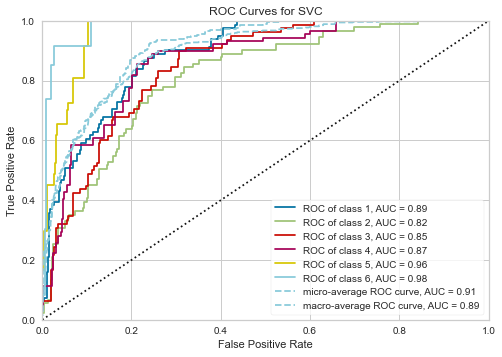

<AxesSubplot:title={'center':'ROC Curves for SVC'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [17]:
visualizer.fit(X_train, y_train)        # Fit the training data to the visualizer
visualizer.score(X_test, y_test)        # Evaluate the model on the test data
visualizer.show()        

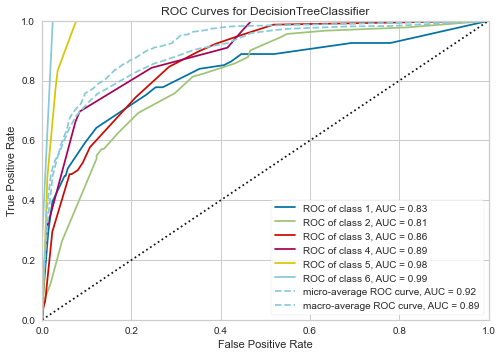

<AxesSubplot:title={'center':'ROC Curves for DecisionTreeClassifier'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [18]:
visualizer_1.fit(X_train, y_train)        # Fit the training data to the visualizer
visualizer_1.score(X_test, y_test)        # Evaluate the model on the test data
visualizer_1.show()        

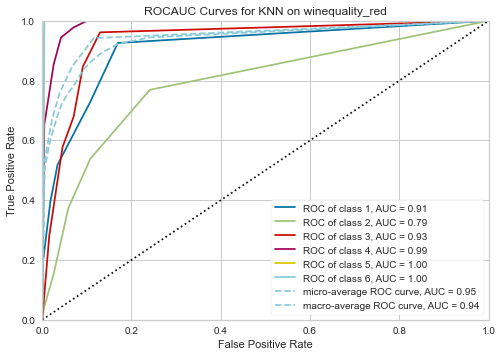

<AxesSubplot:title={'center':'ROCAUC Curves for KNN on winequality_red'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [19]:
visualizer_2.fit(X_train, y_train)        # Fit the training data to the visualizer
visualizer_2.score(X_test, y_test)        # Evaluate the model on the test data
visualizer_2.show()    